# Regresión — Dataset de Venta de Automóviles (processes2.csv)

Ejemplo de **Regresión** empleando el dataset `processes2.csv`, que contiene información sobre vehículos de segunda mano y sus precios de venta.

**Variable objetivo (dependiente):**
- `selling_price` — precio de venta del vehículo.

**Características (variables independientes):**
- `name` — marca del automóvil.
- `year` — año de fabricación.
- `km_driven` — kilómetros recorridos.
- `fuel` — tipo de combustible (Diesel, Petrol, CNG, LPG).
- `seller_type` — tipo de vendedor (Individual, Dealer, Trustmark Dealer).
- `transmission` — tipo de transmisión (Manual, Automatic).
- `owner` — número de propietarios anteriores.
- `seats` — número de asientos.
- `max_power (in bph)` — potencia máxima en caballos de fuerza.
- `Mileage Unit` — unidad de rendimiento (kmpl, km/kg).
- `Mileage` — rendimiento de combustible.
- `Engine (CC)` — cilindrada del motor en CC.

In [51]:
# Importando las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Cargando el dataset
df = pd.read_csv('processes2.csv', index_col=0)

df.shape

(2095, 13)

## 1. Exploración inicial del dataset

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 2095 entries, 0 to 6256
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                2095 non-null   str    
 1   year                2095 non-null   int64  
 2   selling_price       2095 non-null   int64  
 3   km_driven           2095 non-null   int64  
 4   fuel                2095 non-null   str    
 5   seller_type         2095 non-null   str    
 6   transmission        2095 non-null   str    
 7   owner               2095 non-null   str    
 8   seats               2095 non-null   int64  
 9   max_power (in bph)  2095 non-null   float64
 10  Mileage Unit        2095 non-null   str    
 11  Mileage             2095 non-null   float64
 12  Engine (CC)         2095 non-null   int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 229.1 KB


In [53]:
df.describe()

,year,selling_price,km_driven,seats,max_power (in bph),Mileage,Engine (CC)
count,2095.000000,2.095000e+03,2095.000000,2095.000000,2095.000000,2095.000000,2095.000000
mean,2014.052506,4.272799e+05,67413.593795,5.096897,77.410427,21.397928,1205.078282
std,3.273451,2.326698e+05,41580.846333,0.457000,19.884938,1.209234,245.058696
min,2000.000000,4.595700e+04,1000.000000,4.000000,35.000000,19.600000,624.000000
25%,2012.000000,2.500000e+05,35000.000000,5.000000,67.040000,20.360000,998.000000
50%,2014.000000,3.900000e+05,60000.000000,5.000000,74.000000,21.100000,1248.000000
75%,2017.000000,5.555000e+05,90000.000000,5.000000,88.730000,22.540000,1396.000000
max,2020.000000,1.594000e+06,270000.000000,8.000000,126.320000,23.590000,1598.000000


## 2. Revisión de valores nulos

Verificamos si existen valores nulos en el dataset. Dependiendo del resultado se aplica imputación o eliminación de filas/columnas.

In [54]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"\nTotal de valores nulos en el dataset: {nulos.sum()}")

# Imputación vectorizada — sin ciclos for
cols_numericas = df.select_dtypes(include='number').columns
cols_texto     = df.select_dtypes(include='str').columns

# Numéricas: reemplazar nulos con la mediana de cada columna
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

# Categóricas: reemplazar nulos con la moda de cada columna
df[cols_texto] = df[cols_texto].fillna(df[cols_texto].mode().iloc[0])

print("Valores nulos tras imputación:", df.isnull().sum().sum())

Valores nulos por columna:
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
seats                 0
max_power (in bph)    0
Mileage Unit          0
Mileage               0
Engine (CC)           0
dtype: int64

Total de valores nulos en el dataset: 0
Valores nulos tras imputación: 0


## 3. Conversión de variables texto a numéricas

Las columnas `name`, `fuel`, `seller_type`, `transmission`, `owner` y `Mileage Unit` contienen valores categóricos (texto) que deben convertirse a valores numéricos mediante `LabelEncoder` para que el modelo pueda procesarlos.

In [55]:
# Identificar columnas de texto automáticamente
columnas_categoricas = df.select_dtypes(include='str').columns.tolist()
print("Columnas categóricas detectadas:", columnas_categoricas)

# Codificación vectorizada con OrdinalEncoder — sin ciclos for
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(dtype=int)
df[columnas_categoricas] = oe.fit_transform(df[columnas_categoricas])

# Resumen de clases por columna (vectorizado con pandas apply)
resumen = pd.Series(oe.categories_, index=columnas_categoricas, dtype=object).apply(len).rename('clases')
print("\nClases codificadas por columna:")
print(resumen)

df.head(5)

Columnas categóricas detectadas: ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'Mileage Unit']

Clases codificadas por columna:
name            10
fuel             4
seller_type      3
transmission     2
owner            5
Mileage Unit     2
Name: clases, dtype: int64


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power (in bph),Mileage Unit,Mileage,Engine (CC)
0,5,2014,450000,145500,1,1,1,0,5,74.00,1,23.40,1248
2,3,2010,225000,127000,1,1,1,0,5,90.00,1,23.00,1396
4,3,2017,440000,45000,3,1,1,0,5,81.86,1,20.14,1197
7,8,2011,350000,90000,1,1,1,0,5,67.10,1,23.59,1364
8,1,2013,200000,169000,1,1,1,0,5,68.10,1,20.00,1399


## 4. Selección de características

Se separa la variable objetivo `selling_price` del resto de columnas. Se excluye la columna `Mileage Unit` ya que es redundante con la columna numérica `Mileage` (ambas describen el rendimiento de combustible).

Se entrena un primer RandomForest para calcular la importancia de cada característica y confirmar la selección.

In [56]:
# Variable objetivo
y = df['selling_price']

# Variables de entrada (se elimina la columna objetivo)
X = df.drop(columns=['selling_price'])

print("Forma del conjunto de características X:", X.shape)
print("Características usadas:", X.columns.tolist())

# Importancia de características con un modelo rápido
rf_sel = RandomForestRegressor(n_estimators=50, random_state=42)
rf_sel.fit(X, y)

importancias = pd.Series(rf_sel.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nImportancia de características:")
print(importancias)



# Seleccionamos las características con importancia > 0.01 (umbral mínimo)
caracteristicas_sel = importancias[importancias > 0.01].index.tolist()
print("\nCaracterísticas seleccionadas (importancia > 0.01):", caracteristicas_sel)
X = X[caracteristicas_sel]

Forma del conjunto de características X: (2095, 12)
Características usadas: ['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'seats', 'max_power (in bph)', 'Mileage Unit', 'Mileage', 'Engine (CC)']

Importancia de características:
max_power (in bph)    0.542546
year                  0.272998
Engine (CC)           0.060296
km_driven             0.049156
Mileage               0.034575
name                  0.020052
owner                 0.008083
seats                 0.004878
seller_type           0.003660
transmission          0.002469
fuel                  0.001232
Mileage Unit          0.000055
dtype: float64

Características seleccionadas (importancia > 0.01): ['max_power (in bph)', 'year', 'Engine (CC)', 'km_driven', 'Mileage', 'name']


## 5. Escalado de características

Para modelos basados en árboles como **Random Forest**, el escalado **no es necesario** porque los árboles de decisión realizan divisiones binarias que no dependen de la magnitud de los valores. Por esta razón, **no se aplica escalado** en este caso.

> El escalado sería necesario si se usaran modelos como Regresión Lineal, SVM o KNN.

## 6. Validación cruzada — 7 corridas (cv=7)

Se aplica `cross_val_score` con 7 pliegues (cv=7) para obtener el **coeficiente de determinación R²** y el **Error Absoluto Medio (MAE)** de cada una de las 7 corridas, junto con sus promedios.

In [57]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# R² por cada corrida
scores_r2 = cross_val_score(rf, X, y, cv=7, scoring='r2')

# MAE por cada corrida (neg → positivo con negación)
scores_mae_neg = cross_val_score(rf, X, y, cv=7, scoring='neg_mean_absolute_error')
scores_mae = -scores_mae_neg

# Tabla de resultados sin ciclo for
df_cv = pd.DataFrame({
    'Corrida': range(1, 8),
    'R²': scores_r2,
    'MAE': scores_mae
})

promedio = pd.DataFrame([{'Corrida': 'Promedio', 'R²': scores_r2.mean(), 'MAE': scores_mae.mean()}])
df_cv = pd.concat([df_cv, promedio], ignore_index=True)

print(df_cv.to_string(index=False))

 Corrida       R²          MAE
       1 0.891224 53642.426299
       2 0.870592 55655.242631
       3 0.902229 52138.766578
       4 0.891389 57160.979522
       5 0.898185 54973.914900
       6 0.882868 54027.327607
       7 0.871929 61551.790028
Promedio 0.886917 55592.921081


## 7. Comparación de resultados por corrida

Se muestran el **R²** y el **MAE** (no negativos) de cada una de las 7 corridas junto con sus promedios. sklearn devuelve el MAE como `neg_mean_absolute_error` internamente, pero aquí se presenta ya convertido a positivo mediante negación (`-scores`).

In [58]:
df_resultados = pd.DataFrame({
    'Corrida': range(1, 8),
    'R²': scores_r2,
    'MAE': scores_mae          # ya positivo: -scores_mae_neg
})

promedio = pd.DataFrame([{
    'Corrida': 'Promedio',
    'R²': scores_r2.mean(),
    'MAE': scores_mae.mean()
}])

df_resultados = pd.concat([df_resultados, promedio], ignore_index=True)
print(df_resultados.to_string(index=False))

# Mejor corrida
mejor_r2_idx  = scores_r2.argmax()
mejor_mae_idx = scores_mae.argmin()
print(f"\nMejor R²  → Corrida {mejor_r2_idx + 1}: R² = {scores_r2[mejor_r2_idx]:.6f}")
print(f"Menor MAE → Corrida {mejor_mae_idx + 1}: MAE = {scores_mae[mejor_mae_idx]:.4f}")

 Corrida       R²          MAE
       1 0.891224 53642.426299
       2 0.870592 55655.242631
       3 0.902229 52138.766578
       4 0.891389 57160.979522
       5 0.898185 54973.914900
       6 0.882868 54027.327607
       7 0.871929 61551.790028
Promedio 0.886917 55592.921081

Mejor R²  → Corrida 3: R² = 0.902229
Menor MAE → Corrida 3: MAE = 52138.7666


## 8. Diagrama de dispersión — Valores Reales vs. Predicciones

Se realiza una sola corrida de entrenamiento/prueba (80/20) para generar las visualizaciones.

Corrida única — R²: 0.889493  |  MAE: 49068.2483


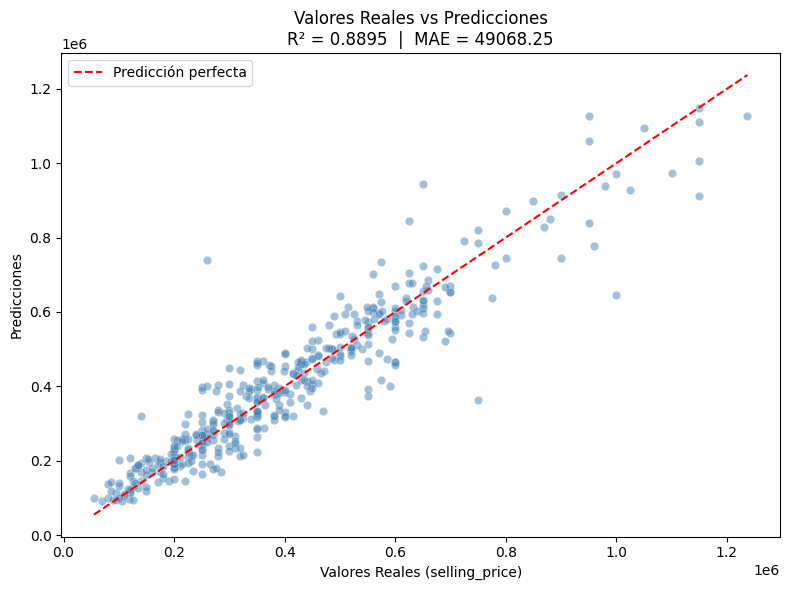

In [59]:
# División única para las gráficas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_unico = RandomForestRegressor(n_estimators=100, random_state=42)
rf_unico.fit(X_train, y_train)
y_pred = rf_unico.predict(X_test)

# Métricas de esta corrida
r2_unico = r2_score(y_test, y_pred)
mae_unico = mean_absolute_error(y_test, y_pred)
print(f"Corrida única — R²: {r2_unico:.6f}  |  MAE: {mae_unico:.4f}")

# --- Diagrama de dispersión ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valores Reales (selling_price)')
plt.ylabel('Predicciones')
plt.title(f'Valores Reales vs Predicciones\nR² = {r2_unico:.4f}  |  MAE = {mae_unico:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Distribución de los residuos

Los **residuos** son la diferencia entre los valores reales y los predichos. En un modelo bien ajustado, los residuos deben distribuirse aproximadamente de forma normal con media cercana a cero, sin sesgos sistemáticos.

Media de residuos  : -1,287.60
Std de residuos    : 72,349.76
Mín residuo        : -479,399.95
Máx residuo        : 385,566.67


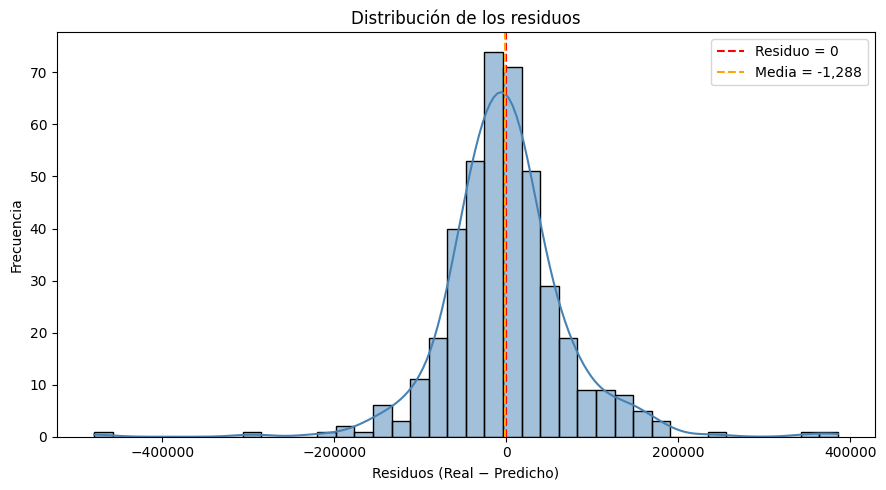

In [60]:
residuos = y_test - y_pred

print(f"Media de residuos  : {residuos.mean():,.2f}")
print(f"Std de residuos    : {residuos.std():,.2f}")
print(f"Mín residuo        : {residuos.min():,.2f}")
print(f"Máx residuo        : {residuos.max():,.2f}")

plt.figure(figsize=(9, 5))
sns.histplot(residuos, kde=True, color='steelblue', bins=40)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo = 0')
plt.axvline(residuos.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Media = {residuos.mean():,.0f}')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos (Real − Predicho)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()